# Dataset


## Imports


In [10]:
import os
import subprocess
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Constants


In [27]:
np.random.seed(42)

os.environ["SUMO_HOME"] = os.path.join(os.environ["CONDA_PREFIX"], "Lib", "site-packages", "sumo")
SUMO_HOME = os.environ["SUMO_HOME"]
os.environ["PATH"] += os.pathsep + os.path.join(SUMO_HOME, "bin")
os.environ["PATH"] += os.pathsep + os.path.join(SUMO_HOME, "tools")

DATASET_DIR = os.path.join("athens-osmWebWizard")

NETWORK_PATH = os.path.join(DATASET_DIR, "osm.net.xml.gz")
RANDOM_TRIPS_PATH = os.path.join(SUMO_HOME, "tools", "randomTrips.py")
DUAROUTER_PATH = os.path.join(SUMO_HOME, "bin", "duarouter.exe")

VEHICLE_TYPES_PROBABILITIES = {"car": 0.91, "truck": 0.06, "bus": 0.03}

TRAIN_TRAFFIC_GENERATION_PERIODS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.9, 0.8, 0.7, 0.6, 0.5]
TEST_TRAFFIC_GENERATION_PERIODS = [p * np.random.uniform(0.95, 1.05) for p in TRAIN_TRAFFIC_GENERATION_PERIODS]

## Random Trips


In [28]:
def simulate_scenario(prefix, traffic_generation_periods, simulation_start=0, simulation_end=36000, seed=42):
    traffic_generation_periods_str = ",".join(str(v) for v in traffic_generation_periods)
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    routes_temp_file = "routes.rou.xml"

    command = [
        "python",
        RANDOM_TRIPS_PATH,
        "--net-file",
        NETWORK_PATH,
        "--begin",
        str(simulation_start),
        "--end",
        str(simulation_end),
        "--period",
        traffic_generation_periods_str,
        "-o",
        trips_file,
        "--seed",
        str(seed),
        "--validate",
    ]

    print("Executing:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)
    if result.stderr:
        print("Errors/Warnings from randomTrips:")
        print(result.stderr)

    if os.path.exists(trips_file) and os.path.exists(routes_temp_file):
        os.remove(routes_temp_file)
        print("Success:", trips_file)
    else:
        print("Failed:", trips_file)


print("Generating train random trips...")
simulate_scenario("train", TRAIN_TRAFFIC_GENERATION_PERIODS, 0, 36000, 0)
print("Generating test random trips...")
simulate_scenario("test", TEST_TRAFFIC_GENERATION_PERIODS, 0, 36000, 1)

Generating train random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.5,0.6,0.7,0.8,0.9,0.9,0.8,0.7,0.6,0.5 -o athens-osmWebWizard\train.trips.xml --seed 0 --validate
Success: athens-osmWebWizard\train.trips.xml
Generating test random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.4937270059423681,0.627042858384595,0.7162395759267983,0.807892678735763,0.8690416776398193,0.8690395068302582,0.764646688973456,0.7256323302042453,0.6060669007045926,0.5104036288898023 -o athens-osmWebWizard\test.trips.xml --seed 1 --validate
Success: athens-osmWebWizard\test.trips.xml


## Trip IDs


In [29]:
def update_trip_ids(prefix):
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    if not os.path.exists(trips_file):
        print(f"Trips file not found: {trips_file}")
        return

    tree = ET.parse(trips_file)
    root = tree.getroot()

    trip_id = 0
    for trip in root.findall("trip"):
        trip.set("id", str(trip_id))
        trip_id += 1

    tree.write(trips_file)
    print("Updated:", trips_file)


print("Updating train trip IDs...")
update_trip_ids("train")
print("Updating test trip IDs...")
update_trip_ids("test")

Updating train trip IDs...
Updated: athens-osmWebWizard\train.trips.xml
Updating test trip IDs...
Updated: athens-osmWebWizard\test.trips.xml


## Vehicle Types


In [30]:
def update_vehicle_types(prefix):
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    if not os.path.exists(trips_file):
        print(f"Trips file not found: {trips_file}")
        return

    tree = ET.parse(trips_file)
    root = tree.getroot()

    for trip in root.findall("trip"):
        random_vehicle_type = np.random.choice(
            list(VEHICLE_TYPES_PROBABILITIES.keys()),
            p=list(VEHICLE_TYPES_PROBABILITIES.values()),
        )
        trip.set("type", random_vehicle_type)

    tree.write(trips_file)
    print("Updated:", trips_file)


print("Updating train vehicle types...")
update_vehicle_types("train")
print("Updating test vehicle types...")
update_vehicle_types("test")

Updating train vehicle types...
Updated: athens-osmWebWizard\train.trips.xml
Updating test vehicle types...
Updated: athens-osmWebWizard\test.trips.xml


## Fixed Routes


In [31]:
def generate_fixed_routes():
    fixed_flows_file = os.path.join(DATASET_DIR, "fixed.flows.xml")
    fixed_routes_file = os.path.join(DATASET_DIR, "fixed.rou.xml")
    fixed_routes_alt_file = os.path.join(DATASET_DIR, "fixed.rou.alt.xml")

    command = [
        DUAROUTER_PATH,
        "--net-file",
        NETWORK_PATH,
        "--route-files",
        fixed_flows_file,
        "--output-file",
        fixed_routes_file,
    ]

    print("Executing:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)

    if result.stderr:
        print("Errors/Warnings from duarouter:")
        print(result.stderr)

    if os.path.exists(fixed_routes_file) and os.path.exists(fixed_routes_alt_file):
        os.remove(fixed_routes_alt_file)
        print("Success:", fixed_routes_file)
    else:
        print("Failed:", fixed_routes_file)


generate_fixed_routes()

Executing: C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\bin\duarouter.exe --net-file athens-osmWebWizard\osm.net.xml.gz --route-files athens-osmWebWizard\fixed.flows.xml --output-file athens-osmWebWizard\fixed.rou.xml
Success: athens-osmWebWizard\fixed.rou.xml


## Simulation


In [32]:
def simulate_scenario(prefix):
    configuration_file = os.path.join(DATASET_DIR, f"{prefix}.sumocfg")
    command = [
        "sumo",
        "-c",
        configuration_file,
    ]

    print("Executing:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)
    if result.stderr:
        print("Errors/Warnings from randomTrips:")
        print(result.stderr)

    print("Simulation completed:", configuration_file)


print("Simulating the train scenario...")
simulate_scenario("train")
print("Simulating the test scenario...")
simulate_scenario("test")

Simulating the train scenario...
Executing: sumo -c athens-osmWebWizard\train.sumocfg
Errors/Warnings from randomTrips:

Simulation completed: athens-osmWebWizard\train.sumocfg
Simulating the test scenario...
Executing: sumo -c athens-osmWebWizard\test.sumocfg
Errors/Warnings from randomTrips:

Simulation completed: athens-osmWebWizard\test.sumocfg


## XML Parsing


In [33]:
def parse_netstate(file_path):
    records = []
    context = ET.iterparse(file_path, events=("end",))
    for _, elem in context:
        if elem.tag == "timestep":
            time = float(elem.get("time"))
            for edge in elem.findall("edge"):
                edge_id = edge.get("id")
                for lane in edge.findall("lane"):
                    lane_id = lane.get("id")
                    for veh in lane.findall("vehicle"):
                        speed_ms = float(veh.get("speed"))
                        records.append(
                            {
                                "timestep_time": time,
                                "edge_id": edge_id,
                                "lane_id": lane_id,
                                "vehicle_id": veh.get("id"),
                                "position": float(veh.get("pos")),
                                "speed_kmh": speed_ms * 3.6,
                            }
                        )
            elem.clear()
    df = pd.DataFrame(records)
    return df


dataset_path = os.path.join(DATASET_DIR, "dump-train-athens-10h.xml")
df = parse_netstate(dataset_path)

## Overview


In [34]:
df = df.dropna().reset_index(drop=True)

print("Data shape:", df.shape)
print(df[["timestep_time", "speed_kmh", "position"]].describe())
print("Unique vehicles:", df["vehicle_id"].nunique())
print("Time span: {:.2f} s to {:.2f} s".format(df["timestep_time"].min(), df["timestep_time"].max()))

Data shape: (11216909, 6)
       timestep_time     speed_kmh      position
count   1.121691e+07  1.121691e+07  1.121691e+07
mean    1.800162e+04  2.850337e+01  4.123625e+01
std     1.156006e+04  2.298651e+01  4.734638e+01
min     0.000000e+00  0.000000e+00  0.000000e+00
25%     6.917000e+03  5.760000e+00  9.810000e+00
50%     1.792100e+04  2.743200e+01  3.036000e+01
75%     2.906000e+04  4.464000e+01  5.871000e+01
max     3.644600e+04  1.318680e+02  9.311900e+02
Unique vehicles: 51721
Time span: 0.00 s to 36446.00 s


## Data Engineering


In [35]:
df["second"] = df["timestep_time"].astype(int)
df["hour"] = (df["timestep_time"] // 3600).astype(int)

secondly = (
    df.groupby("second").agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique")).reset_index()
)

hourly = (
    df.groupby("hour").agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique")).reset_index()
)

## Plots


### Speed Distribution


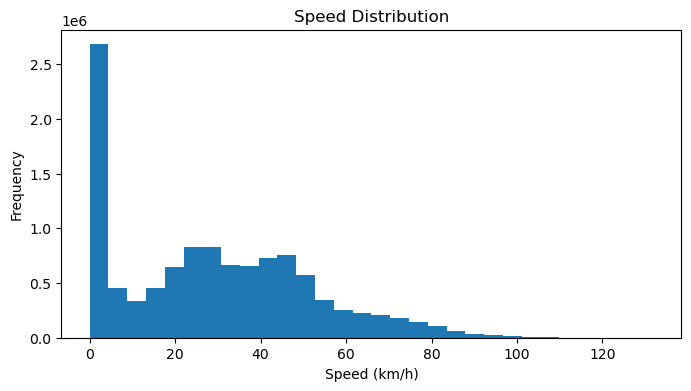

In [36]:
plt.figure(figsize=(8, 4))
plt.hist(df["speed_kmh"], bins=30)
plt.title("Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.show()

### Average Speed per Second


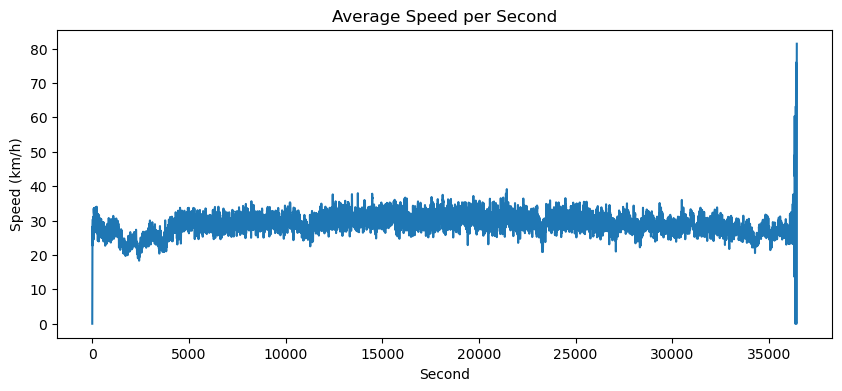

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(secondly["second"], secondly["avg_speed_kmh"])
plt.title("Average Speed per Second")
plt.xlabel("Second")
plt.ylabel("Speed (km/h)")
plt.show()

### Vehicle Count per Second


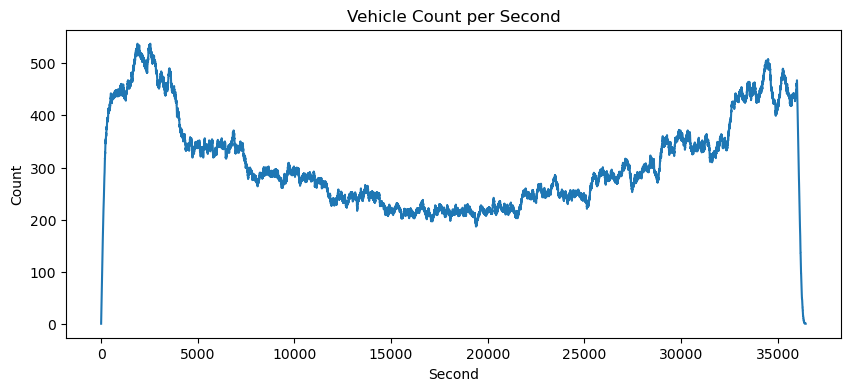

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(secondly["second"], secondly["vehicle_count"])
plt.title("Vehicle Count per Second")
plt.xlabel("Second")
plt.ylabel("Count")
plt.show()

### Average Speed per Hour


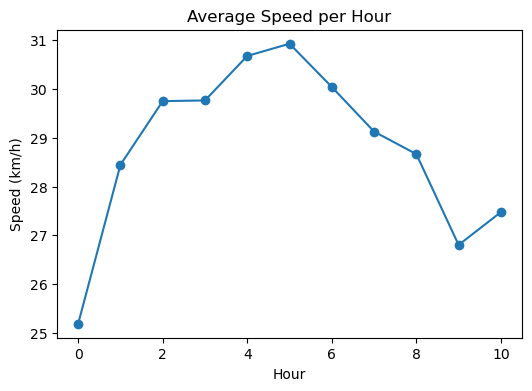

In [39]:
plt.figure(figsize=(6, 4))
plt.plot(hourly["hour"], hourly["avg_speed_kmh"], marker="o")
plt.title("Average Speed per Hour")
plt.xlabel("Hour")
plt.ylabel("Speed (km/h)")
plt.show()

### Vehicle Count per Hour


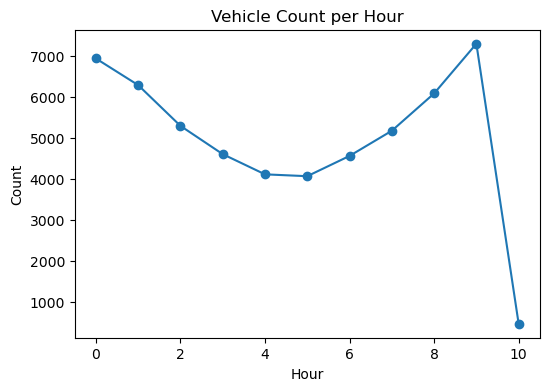

In [40]:
plt.figure(figsize=(6, 4))
plt.plot(hourly["hour"], hourly["vehicle_count"], marker="o")
plt.title("Vehicle Count per Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

### Vehicle Count and Speed over Time


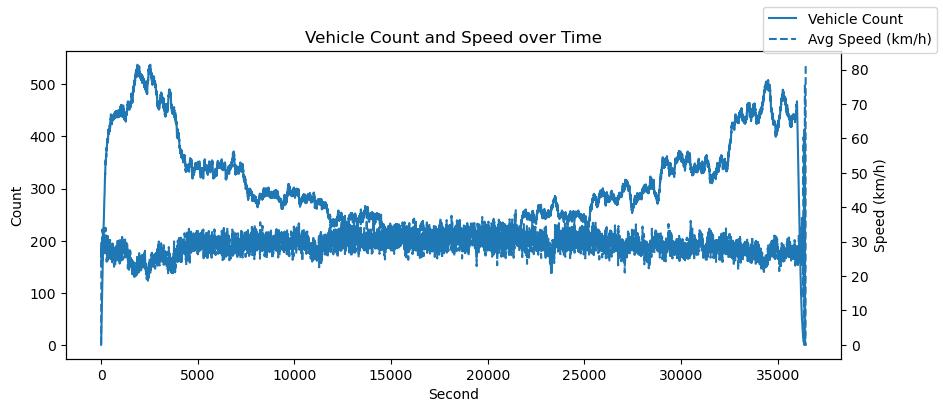

In [41]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(secondly["second"], secondly["vehicle_count"], label="Vehicle Count")
ax1.set_xlabel("Second")
ax1.set_ylabel("Count")
ax2 = ax1.twinx()
ax2.plot(secondly["second"], secondly["avg_speed_kmh"], label="Avg Speed (km/h)", linestyle="--")
ax2.set_ylabel("Speed (km/h)")
fig.legend(loc="upper right")
plt.title("Vehicle Count and Speed over Time")
plt.show()

### Average Speed and Traffic Generation Periods per Hour


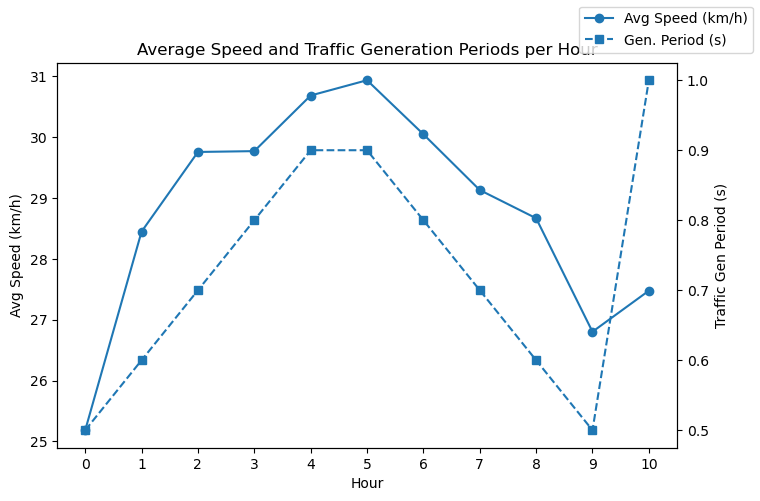

In [42]:
extended_train_traffic_generation_periods = TRAIN_TRAFFIC_GENERATION_PERIODS + [1.0]
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(hourly["hour"], hourly["avg_speed_kmh"], marker="o", label="Avg Speed (km/h)")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Avg Speed (km/h)")
ax1.set_xticks(hourly["hour"])
ax2 = ax1.twinx()
ax2.plot(hourly["hour"], extended_train_traffic_generation_periods, marker="s", linestyle="--", label="Gen. Period (s)")
ax2.set_ylabel("Traffic Gen Period (s)")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
plt.title("Average Speed and Traffic Generation Periods per Hour")
plt.show()